##### This code was done with a lil' help from ChatGPT ;  This code never deletes anything 

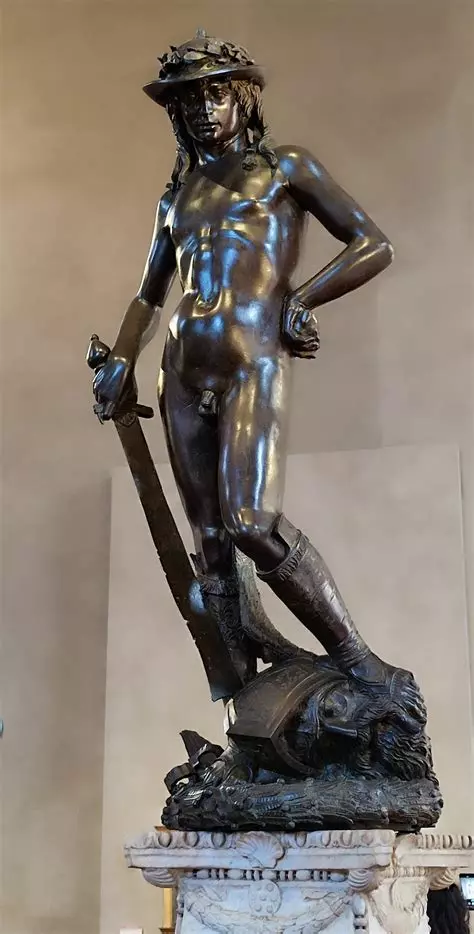

# ------------------
# Fighting the giant 
# ------------------

### Google makes it impossible for you to get out. How? If you have an album structure a lil more complex than just yearly albums, Google splits some albums across different folders, so you have to merge them back together
### And from trying with Google Takeout Helper, format problems arose for me (and it did not handle my use case of split albums)
### What's the idea of the code? : doing just that
### For now it leaves aside the trouble to merge the JSON metadata with the proper picture - but no worries they're copied too so we don't lose them

### NB : U'll still have manual stuff to do : "Untitled(X)" ones, "Failed videos" or other titles made by Google from which you can understand something went wrong. Go manually through them and if they're not valuable, delete. 

In [ ]:
#### Structure : create BIG_FOLDER containing all the Takeout subfolders made by Google

In [1]:
from pathlib import Path
from collections import defaultdict
import os

# ============================================
# CONFIGURE THIS
# ============================================

BIG_FOLDER = "your_path"

# ============================================
# SCRIPT
# ============================================

ALBUMS = list()
big_path = Path(BIG_FOLDER)

# All top-level Takeout folders
takeout_folders = [p for p in big_path.iterdir() if p.is_dir()]

album_occurrences = defaultdict(set)

for takeout_root in takeout_folders:

    google_photos_path = (
        takeout_root / "Takeout" / "Google\xa0Photos"
    )
    print(repr(google_photos_path))
    if not google_photos_path.exists():
        print(f"Missing: {google_photos_path}")
        continue

    # Albums are directly inside Google Photos
    for album_folder in google_photos_path.iterdir():

        if not album_folder.is_dir():
            continue

        album_name = album_folder.name

        # Record which Takeout folder contains it
        album_occurrences[album_name].add(takeout_root.name)

# ============================================
# RESULTS
# ============================================

results = sorted(
    (
        album_name,
        len(roots),
        sorted(roots)
    )
    for album_name, roots in album_occurrences.items()
)

# ============================================
# OUTPUT
# ============================================

for album_name, count, roots in results:

    if count == 1:
        ALBUMS.add(album_name)
        
    print("=" * 70)
    print(album_name)
    print(f"Appears in {count} Takeout folder(s):")

    for r in roots:
        print(f"  - {r}")
print("\nDONE")

FileNotFoundError: [WinError 3] Le chemin d’accès spécifié est introuvable: 'D:\\Takeout_all'

In [ ]:
from pathlib import Path
import hashlib

# ============================================
# CONFIGURE THIS
# ============================================
path0=BIG_FOLDER+r"\takeout-20250721T211441Z-1-001\Takeout\Google Photos"

# ============================================

root = Path(path0)

def file_hash(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while chunk := f.read(8192):
            h.update(chunk)
    return h.hexdigest()

hashes = {}
duplicates = []

for file in root.rglob("*"):
    if file.is_file():
        try:
            h = file_hash(file)
            if h in hashes:
                duplicates.append((file, hashes[h]))
            else:
                hashes[h] = file
        except:
            pass

print("Duplicate files:", len(duplicates))

### Copying the album not split across takeout_XXX folders into one folder to treat the split album problem later

In [ ]:
from pathlib import Path
import shutil

# ============================================
# CONFIG
# ============================================

BIG_FOLDER = r"your_input_folder"
OUTPUT_FOLDER = r"your_output_folder"


# ============================================
# SETUP
# ============================================

big_path = Path(BIG_FOLDER)
output_path = Path(OUTPUT_FOLDER)
output_path.mkdir(parents=True, exist_ok=True)

# normalize for matching
target_albums = {a.strip().lower(): a for a in ALBUMS}

# track what we found
found = set()

# ============================================
# SEARCH + COPY
# ============================================

for folder in big_path.rglob("*"):
    if not folder.is_dir():
        continue

    name_norm = folder.name.strip().lower()

    if name_norm in target_albums:
        album_name = target_albums[name_norm]

        # avoid copying same album twice
        if album_name in found:
            continue

        print(f"FOUND: {album_name} -> {folder}")

        dest = output_path / album_name

        # copy whole folder as-is
        if dest.exists():
            print(f"SKIP (already exists): {album_name}")
            continue

        shutil.copytree(folder, dest)
        found.add(album_name)

# ============================================
# SUMMARY
# ============================================

print("\n========== DONE ==========")
print(f"Copied {len(found)} albums to {output_path}")
print("len(ALBUMS) =", len(ALBUMS))

### had done manual selection of album which were present only once (not split across takeout_XXX albums)
### you can try to automate it, I just semi-manualy did it

### Normalizing weird album names to not have character reading problems

In [ ]:
from pathlib import Path
import unicodedata

# ============================================================
# RAW ALBUM LIST (as provided)
# ============================================================

RAW_ALBUMS = """
Album1
Album2
...
"""

# ============================================================
# NORMALIZATION FUNCTION (handles weird names safely)
# ============================================================

def normalize(name: str) -> str:
    # remove accents (É → E)
    name = unicodedata.normalize("NFKD", name)
    name = "".join(c for c in name if not unicodedata.combining(c))

    # trim + lowercase
    return name.strip().lower()

# ============================================================
# MEMORY STRUCTURE
# ============================================================

# maps normalized → original (safe matching)
ALBUM_MEMORY = {
    normalize(name): name
    for name in RAW_ALBUMS.splitlines()
    if name.strip()
}

# ============================================================
# QUICK SAFETY CHECK
# ============================================================

print("Albums loaded:", len(ALBUM_MEMORY))
print("Example key '_3':", "_3" in ALBUM_MEMORY)
print(ALBUM_MEMORY)

In [ ]:
from pathlib import Path
import shutil

# ============================================================
# CONFIG
# ============================================================

ROOT = Path(BIG_FOLDER)
OUTPUT = Path(BIG_FOLDER)
OUTPUT.mkdir(exist_ok=True)

# memory: albums already fully processed UNCOMMENT LATER
#done_albums = set(ALBUM_MEMORY.keys())

# ============================================================
# STEP 1: gather Takeout roots
# ============================================================

takeout_roots = [p for p in ROOT.iterdir() if p.is_dir()]

# ============================================================
# STEP 2: scan everything
# ============================================================

for takeout in takeout_roots:

    for gp_root in takeout.rglob("Takeout/Google\xa0Photos"):

        for album_folder in gp_root.iterdir():

            if not album_folder.is_dir():
                continue

            album_name = album_folder.name

            # ====================================================
            # FIRST OCCURRENCE ONLY: trigger full collection
            # ====================================================

            if normalize(album_name) in done_albums:
                continue  # already fully processed earlier

            print(f"\n[NEW ALBUM] {album_name}")

            done_albums.add(normalize(album_name))

            # output folder
            target_album = OUTPUT / album_name
            target_album.mkdir(parents=True, exist_ok=True)

            # ====================================================
            # NOW: collect ALL occurrences of this album everywhere
            # ====================================================

            for other_takeout in takeout_roots:
                for gp in other_takeout.rglob("Takeout/Google\xa0Photos"):

                    candidate = gp / album_name

                    if candidate.is_dir():

                        print(f"  + merging from {candidate}")

                        for item in candidate.rglob("*"):

                            if item.is_file():

                                rel = item.relative_to(candidate)
                                dest = target_album / rel

                                dest.parent.mkdir(parents=True, exist_ok=True)

                                shutil.copy2(item, dest)

# ============================================================
# DONE
# ============================================================

print("\nDONE →", OUTPUT)
print("Albums processed:", len(done_albums))

In [ ]:
done_albums